# Milestone 1 — Data Exploration and Preprocessing
## Amazon All_Beauty Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

## 1. Loading the Data

In [3]:
# Loading first 200 rows of reviews
reviews = []
with open('../data/raw/All_Beauty.jsonl', 'r') as f:
    for i, line in enumerate(f):
        if i >= 200:
            break
        reviews.append(json.loads(line))

reviews_df = pd.DataFrame(reviews)
print(f"Reviews shape: {reviews_df.shape}")
reviews_df.head()

Reviews shape: (200, 10)


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Such a lovely scent but not overpowering.,"This spray is really nice. It smells really good, goes on really fine, and does the trick. I wil...",[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1588687728923,0,True
1,4.0,Works great but smells a little weird.,"This product does what I need it to do, I just wish it was odorless or had a soft coconut smell....",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1588615855070,1,True
2,5.0,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,1589665266052,2,True
3,1.0,Synthetic feeling,Felt synthetic,[],B09JS339BZ,B09JS339BZ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,1643393630220,0,True
4,5.0,A+,Love it,[],B08BZ63GMJ,B08BZ63GMJ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,1609322563534,0,True


In [4]:
# Loading first 200 rows of metadata
metadata = []
with open('../data/raw/meta_All_Beauty.jsonl', 'r') as f:
    for i, line in enumerate(f):
        if i >= 200:
            break
        metadata.append(json.loads(line))

meta_df = pd.DataFrame(metadata)
print(f"Metadata shape: {meta_df.shape}")
meta_df.head()

Metadata shape: (200, 14)


,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,All Beauty,"Howard LC0008 Leather Conditioner, 8-Ounce (4-Pack)",4.8,10,[],[],NaN,"[{'thumb': 'https://m.media-amazon.com/images/I/41qfjSfqNyL._SS40_.jpg', 'large': 'https://m.med...",[],Howard Products,[],"{'Package Dimensions': '7.1 x 5.5 x 3 inches; 2.38 Pounds', 'UPC': '617390882781'}",B01CUPMQZE,None
1,All Beauty,"Yes to Tomatoes Detoxifying Charcoal Cleanser (Pack of 2) with Charcoal Powder, Tomato Fruit Ext...",4.5,3,[],[],NaN,"[{'thumb': 'https://m.media-amazon.com/images/I/41b+11d5igL._SS40_.jpg', 'large': 'https://m.med...",[],Yes To,[],"{'Item Form': 'Powder', 'Skin Type': 'Acne Prone', 'Brand': 'Yes To', 'Age Range (Description)':...",B076WQZGPM,None
2,All Beauty,Eye Patch Black Adult with Tie Band (6 Per Pack),4.4,26,[],[],NaN,"[{'thumb': 'https://m.media-amazon.com/images/I/31bz+uqzWCL._SS40_.jpg', 'large': 'https://m.med...",[],Levine Health Products,[],{'Manufacturer': 'Levine Health Products'},B000B658RI,None
3,All Beauty,"Tattoo Eyebrow Stickers, Waterproof Eyebrow, 4D Imitation Eyebrow Tattoos, 4D Hair-like Authenti...",3.1,102,[],[],NaN,"[{'thumb': 'https://m.media-amazon.com/images/I/515iwxdKS1L._SS40_.jpg', 'large': 'https://m.med...",[],Cherioll,[],"{'Brand': 'Cherioll', 'Item Form': 'Powder', 'Finish Type': 'Natural', 'Product Benefits': 'Long...",B088FKY3VD,None
4,All Beauty,Precision Plunger Bars for Cartridge Grips – 93mm – Bag of 10 Plungers,4.3,7,"[Material: 304 Stainless Steel; Brass tip, Lengths Available: 88mm, 93mm, 98mm, Accepts cartridg...","[The Precision Plunger Bars are designed to work seamlessly with the Precision Disposable 1. 25""...",NaN,"[{'thumb': 'https://m.media-amazon.com/images/I/31TgqAZ8kQL._SS40_.jpg', 'large': 'https://m.med...",[],Precision,[],{'UPC': '644287689178'},B07NGFDN6G,None


## 2. Dataset Overview

In [5]:
print("=== REVIEWS ===")
print(f"Shape: {reviews_df.shape}")
print(f"\nColumns: {reviews_df.columns.tolist()}")
print(f"\nData types:\n{reviews_df.dtypes}")
print(f"\nMissing values:\n{reviews_df.isnull().sum()}")

=== REVIEWS ===
Shape: (200, 10)

Columns: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']

Data types:
rating               float64
title                    str
text                     str
images                object
asin                     str
parent_asin              str
user_id                  str
timestamp              int64
helpful_vote           int64
verified_purchase       bool
dtype: object

Missing values:
rating               0
title                0
text                 0
images               0
asin                 0
parent_asin          0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
dtype: int64


In [6]:
print("=== METADATA ===")
print(f"Shape: {meta_df.shape}")
print(f"\nColumns: {meta_df.columns.tolist()}")
print(f"\nData types:\n{meta_df.dtypes}")
print(f"\nMissing values:\n{meta_df.isnull().sum()}")

=== METADATA ===
Shape: (200, 14)

Columns: ['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together']

Data types:
main_category          str
title                  str
average_rating     float64
rating_number        int64
features            object
description         object
price              float64
images              object
videos              object
store                  str
categories          object
details             object
parent_asin            str
bought_together     object
dtype: object

Missing values:
main_category        0
title                0
average_rating       0
rating_number        0
features             0
description          0
price              161
images               0
videos               0
store               19
categories           0
details              0
parent_asin          0
bought_together    200
dtype: int64


## 3. Sample Records

In [7]:
print("=== SAMPLE REVIEW ===")
print(reviews_df.iloc[0].to_dict())

=== SAMPLE REVIEW ===
{'rating': 5.0, 'title': 'Such a lovely scent but not overpowering.', 'text': "This spray is really nice. It smells really good, goes on really fine, and does the trick. I will say it feels like you need a lot of it though to get the texture I want. I have a lot of hair, medium thickness. I am comparing to other brands with yucky chemicals so I'm gonna stick with this. Try it!", 'images': [], 'asin': 'B00YQ6X8EO', 'parent_asin': 'B00YQ6X8EO', 'user_id': 'AGKHLEW2SOWHNMFQIJGBECAF7INQ', 'timestamp': 1588687728923, 'helpful_vote': 0, 'verified_purchase': True}


In [8]:
print("=== SAMPLE METADATA ===")
print(meta_df.iloc[0].to_dict())

=== SAMPLE METADATA ===
{'main_category': 'All Beauty', 'title': 'Howard LC0008 Leather Conditioner, 8-Ounce (4-Pack)', 'average_rating': 4.8, 'rating_number': 10, 'features': [], 'description': [], 'price': nan, 'images': [{'thumb': 'https://m.media-amazon.com/images/I/41qfjSfqNyL._SS40_.jpg', 'large': 'https://m.media-amazon.com/images/I/41qfjSfqNyL.jpg', 'variant': 'MAIN', 'hi_res': None}, {'thumb': 'https://m.media-amazon.com/images/I/41w2yznfuZL._SS40_.jpg', 'large': 'https://m.media-amazon.com/images/I/41w2yznfuZL.jpg', 'variant': 'PT01', 'hi_res': 'https://m.media-amazon.com/images/I/71i77AuI9xL._SL1500_.jpg'}], 'videos': [], 'store': 'Howard Products', 'categories': [], 'details': {'Package Dimensions': '7.1 x 5.5 x 3 inches; 2.38 Pounds', 'UPC': '617390882781'}, 'parent_asin': 'B01CUPMQZE', 'bought_together': None}


## 4. Field Selection for Retrieval

In [9]:
# Fields selected for retrieval
# From reviews: text, title, rating
# From metadata: title, features, description

print("=== SELECTED REVIEW FIELDS ===")
print(reviews_df[['asin', 'title', 'text', 'rating']].head())

print("\n=== SELECTED METADATA FIELDS ===")
print(meta_df[['parent_asin', 'title', 'features', 'description']].head())

=== SELECTED REVIEW FIELDS ===
         asin                                      title  \
0  B00YQ6X8EO  Such a lovely scent but not overpowering.   
1  B081TJ8YS3     Works great but smells a little weird.   
2  B07PNNCSP9                                       Yes!   
3  B09JS339BZ                          Synthetic feeling   
4  B08BZ63GMJ                                         A+   

                                                                                                  text  \
0  This spray is really nice. It smells really good, goes on really fine, and does the trick. I wil...   
1  This product does what I need it to do, I just wish it was odorless or had a soft coconut smell....   
2                                                                            Smells good, feels great!   
3                                                                                       Felt synthetic   
4                                                                             

## 5. Text Preprocessing Decisions

For retrieval, we will combine the following fields into a single document string:

- **From metadata**: `title`, `features`, `description`
- **From reviews**: `title`, `text`

**Justification**:
- `title` (metadata) is the most informative field for keyword and semantic matching
- `features` and `description` provide rich product details for semantic search
- Review `text` captures real user language which helps match natural language queries
- `rating` is kept separately for display purposes only

**Preprocessing steps**:
- Lowercase all text
- Remove punctuation
- Strip extra whitespace
- Join list fields (features, description) into a single string

In [10]:
import re

def preprocess_text(text):
    """Lowercase, remove punctuation, strip extra whitespace."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def join_list_field(field):
    """Join list fields into a single string."""
    if isinstance(field, list):
        return ' '.join([str(i) for i in field])
    return str(field) if field else ""

# Test it
sample_text = "This is a GREAT product! It's amazing... (really)"
print(preprocess_text(sample_text))

sample_list = ["Feature 1", "Feature 2", "Feature 3"]
print(join_list_field(sample_list))

this is a great product its amazing really
Feature 1 Feature 2 Feature 3


In [11]:
# Combining metadata fields into one document string
meta_df['combined_text'] = (
    meta_df['title'].apply(preprocess_text) + ' ' +
    meta_df['features'].apply(join_list_field).apply(preprocess_text) + ' ' +
    meta_df['description'].apply(join_list_field).apply(preprocess_text)
)

print("=== SAMPLE COMBINED METADATA TEXT ===")
print(meta_df['combined_text'].iloc[4])

=== SAMPLE COMBINED METADATA TEXT ===
precision plunger bars for cartridge grips 93mm bag of 10 plungers material 304 stainless steel brass tip lengths available 88mm 93mm 98mm accepts cartridge needles with vice style tattoo machines works perfectly with precision disposable soft cartridge grips price per one bag of 10 plungers the precision plunger bars are designed to work seamlessly with the precision disposable 1 25 contoured soft cartridge grips and the precision disposable 1 textured soft cartridge grips to drive cartridge needles with vice style or standard tattoo machine setups these plunger bars are manufactured from 304 stainless steel and feature a brass tip the plungers are sold in a bag of ten in your choice of 88mm 93mm or 98mm length


In [12]:
# Combine review fields into one document string
reviews_df['combined_text'] = (
    reviews_df['title'].apply(preprocess_text) + ' ' +
    reviews_df['text'].apply(preprocess_text)
)

print("=== SAMPLE COMBINED REVIEW TEXT ===")
print(reviews_df['combined_text'].iloc[0])

=== SAMPLE COMBINED REVIEW TEXT ===
such a lovely scent but not overpowering this spray is really nice it smells really good goes on really fine and does the trick i will say it feels like you need a lot of it though to get the texture i want i have a lot of hair medium thickness i am comparing to other brands with yucky chemicals so im gonna stick with this try it


## 6. Basic EDA

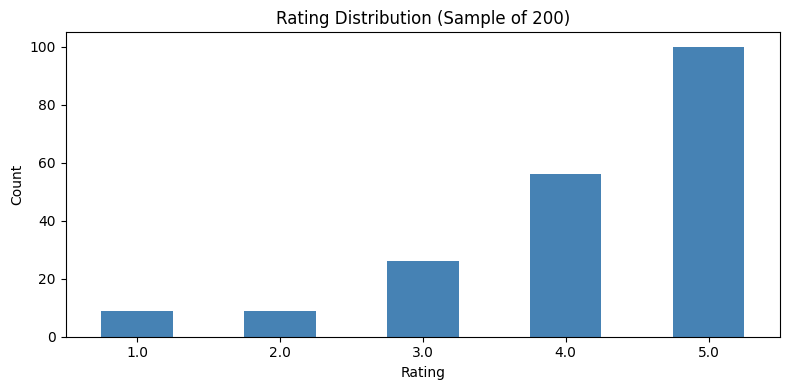

In [13]:
# Rating distribution
plt.figure(figsize=(8, 4))
reviews_df['rating'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Rating Distribution (Sample of 200)')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

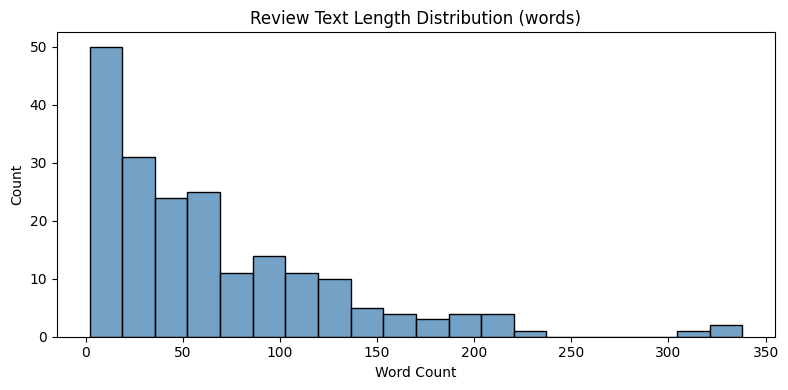

Average review length: 65.9 words
Max review length: 338 words
Min review length: 2 words


In [14]:
# Review text length distribution
reviews_df['text_length'] = reviews_df['text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8, 4))
sns.histplot(reviews_df['text_length'], bins=20, color='steelblue')
plt.title('Review Text Length Distribution (words)')
plt.xlabel('Word Count')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f"Average review length: {reviews_df['text_length'].mean():.1f} words")
print(f"Max review length: {reviews_df['text_length'].max()} words")
print(f"Min review length: {reviews_df['text_length'].min()} words")

In [15]:
# Check overlap between reviews and metadata
review_asins = set(reviews_df['asin'].unique())
meta_asins = set(meta_df['parent_asin'].unique())

overlap = review_asins.intersection(meta_asins)
print(f"Unique ASINs in reviews: {len(review_asins)}")
print(f"Unique ASINs in metadata: {len(meta_asins)}")
print(f"Overlapping ASINs: {len(overlap)}")
print(f"Overlap percentage: {len(overlap)/len(review_asins)*100:.1f}%")

Unique ASINs in reviews: 195
Unique ASINs in metadata: 200
Overlapping ASINs: 1
Overlap percentage: 0.5%


## 7. Summary of Preprocessing Decisions

- **Fields used for retrieval**:
  - Metadata: `title`, `features`, `description` — combined into one document string
  - Reviews: `title`, `text` — combined into one document string
- **Preprocessing steps applied**:
  - Lowercasing
  - Punctuation removal
  - Whitespace normalization
  - List fields joined into strings
- **Fields kept for display**: `rating`, `asin`, `parent_asin`
- **Fields dropped**: `images`, `videos`, `bought_together`, `timestamp`, `user_id`, `helpful_vote`, `verified_purchase`
- **Note**: EDA performed on first 200 rows. Full dataset will be loaded for retrieval.